# Анализ активности пользователей в корзине

Компания хочет повысить эффективность e-commerce воронки. Один из ключевых этапов — добавление товара в корзину. Цель анализа — понять, какие группы пользователей и товаров формируют активность корзины, как она меняется во времени и где наблюдаются отклонения или снижение активности.

- проверка качества данных;
- анализ пользователей;
- анализ товаров;
- временной анализ.

Важно: датасет отражает активность корзины, а не факт покупки или продажи. В проекте используются синтетические данные.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Загрузка и знакомство с данными

In [2]:
customers = pd.read_csv("customers_ecom.csv", index_col="customer_id")

In [3]:
basket = pd.read_csv(
    "basket_ecom_.csv", parse_dates=["basket_date"], index_col="customer_id"
)

## Описание данных

Датасет состоит из таблиц: `customers` и `basket`.

### Таблица `customers`

Содержит информацию о пользователях:

* `customer_id` — ID пользователя;
* `sex` — пол;
* `age` — возраст;
* `tenure` — срок взаимодействия пользователя с сервисом (мес).

### Таблица `basket`

Содержит информацию об активности пользователей при добавлении товаров в корзину:

* `customer_id` — ID пользователя;
* `product_id` — ID товара;
* `basket_date` — дата события;
* `basket_count` — количество событий добавления товара в корзину.

In [4]:
customers.head()

,sex,customer_age,tenure
customer_id,,,
9798859,Male,44.0,93
11413563,Male,36.0,65
818195,Male,35.0,129
12049009,Male,33.0,58
10083045,Male,42.0,88


In [5]:
customers.info()

<class 'pandas.DataFrame'>
Index: 20000 entries, 9798859 to 12572063
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sex           20000 non-null  str    
 1   customer_age  20000 non-null  float64
 2   tenure        20000 non-null  int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 712.3 KB


In [6]:
basket.info()

<class 'pandas.DataFrame'>
Index: 15000 entries, 9798859 to 18442302
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    15000 non-null  int64         
 1   basket_date   15000 non-null  datetime64[us]
 2   basket_count  15000 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 468.8 KB


In [7]:
basket.head()

,product_id,basket_date,basket_count
customer_id,,,
9798859,41475073,2019-06-19,2
11413563,43279538,2019-06-19,2
818195,31715598,2019-06-19,3
12049009,47880260,2019-06-19,2
10083045,44747002,2019-06-19,2


## Проверка качества данных

- пропущенные значения;
- допустимые значения;
- дубликаты;
- корректность типов данных.


In [8]:
customers.describe(include="all")

,sex,customer_age,tenure
count,20000,20000.000000,20000.000000
unique,4,NaN,NaN
top,Male,NaN,NaN
freq,15322,NaN,NaN
mean,NaN,262.222550,44.396800
std,NaN,604.321589,31.998376
min,NaN,-34.000000,4.000000
25%,NaN,29.000000,21.000000
50%,NaN,38.000000,35.000000
75%,NaN,123.000000,60.000000


In [9]:
customers["sex"].value_counts()

sex
Male                15322
Female               4669
kvkktalepsilindi        8
UNKNOWN                 1
Name: count, dtype: int64

In [10]:
customers["sex"] = customers["sex"].replace(["kvkktalepsilindi", "UNKNOWN"], pd.NA)
## Замена некорректных и неизвестных значений пола на пропуски

In [11]:
customers["sex"] = customers["sex"].astype("category")

In [12]:
customers.rename(columns={"customer_age": "age"}, inplace=True)

In [13]:
customers["age"].value_counts()

age
123.0     4539
2022.0    2102
29.0       801
5.0        710
30.0       695
          ... 
4.0          1
130.0        1
115.0        1
6.0          1
127.0        1
Name: count, Length: 93, dtype: int64

In [14]:
customers.loc[(customers["age"] > 100) | (customers["age"] < 6), "age"] = np.nan
# Обнаружены некорректные значения возраста: младше 6 и старше 100 лет.
# Так как реальный возраст неизвестен, некорректные значения заменяем на NaN, чтобы не искажать дальнейший анализ.

In [15]:
customers["age"] = customers["age"].astype("Int8")

In [16]:
customers["tenure"] = customers["tenure"].astype("int32")

In [17]:
basket.shape
basket.info()
basket.describe(include="all")
basket.isna().sum()

<class 'pandas.DataFrame'>
Index: 15000 entries, 9798859 to 18442302
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    15000 non-null  int64         
 1   basket_date   15000 non-null  datetime64[us]
 2   basket_count  15000 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 468.8 KB


product_id      0
basket_date     0
basket_count    0
dtype: int64

In [18]:
basket["product_id"] = basket["product_id"].astype("int32")
basket["basket_count"] = basket["basket_count"].astype("int8")

## Анализ данных

Для удобства объединим таблицы customers и basket по customer_id.


In [19]:
df = customers.merge(basket, how="inner", left_index=True, right_index=True)

In [20]:
df.head()

,sex,age,tenure,product_id,basket_date,basket_count
customer_id,,,,,,
9798859,Male,44,93,41475073,2019-06-19,2
11413563,Male,36,65,43279538,2019-06-19,2
818195,Male,35,129,31715598,2019-06-19,3
12049009,Male,33,58,47880260,2019-06-19,2
10083045,Male,42,88,44747002,2019-06-19,2


In [21]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
Index: 15000 entries, 9798859 to 17035560
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sex           14989 non-null  category      
 1   age           10540 non-null  Int8          
 2   tenure        15000 non-null  int32         
 3   product_id    15000 non-null  int32         
 4   basket_date   15000 non-null  datetime64[us]
 5   basket_count  15000 non-null  int8          
dtypes: Int8(1), category(1), datetime64[us](1), int32(2), int8(1)
memory usage: 410.2 KB


,sex,age,tenure,product_id,basket_date,basket_count
count,14989,10540.0,15000.000000,1.500000e+04,15000,15000.000000
unique,2,<NA>,NaN,NaN,NaN,NaN
top,Male,<NA>,NaN,NaN,NaN,NaN
freq,11361,<NA>,NaN,NaN,NaN,NaN
mean,NaN,34.168786,47.894000,3.269771e+07,2019-06-01 03:44:09.600000,2.153733
min,NaN,12.0,4.000000,4.939000e+04,2019-05-20 00:00:00,2.000000
25%,NaN,28.0,16.000000,3.137412e+07,2019-05-26 00:00:00,2.000000
50%,NaN,32.0,27.000000,3.694759e+07,2019-05-28 00:00:00,2.000000
75%,NaN,39.0,78.000000,4.502408e+07,2019-06-09 00:00:00,2.000000
max,NaN,100.0,133.000000,5.579097e+07,2019-06-19 00:00:00,10.000000


In [22]:
df.groupby("customer_id").size().value_counts().sort_index()
# У большинства пользователей в датасете одна запись о добавлении в корзину
# Пользователи с повторными добавлениями встречаются значительно реже и составляют небольшую долю выборки.

1    12934
2      801
3       99
4       25
5        9
6        1
8        2
Name: count, dtype: int64

In [23]:
customer_activity = df.groupby("customer_id").agg(
    sex=("sex", "first"),
    age=("age", "first"),
    tenure=("tenure", "first"),
    basket_activity=("basket_count", "sum"),
)

In [24]:
customer_activity.head()

,sex,age,tenure,basket_activity
customer_id,,,,
2093,Male,47,133,3
12817,Male,40,132,2
14309,Female,37,131,8
15155,Male,42,131,2
23205,Male,41,131,2


In [25]:
customer_activity.groupby("sex")["basket_activity"].mean()
# Заметных различий в активности добавления товаров в корзину между мужчинами и женщинами не наблюдается.

sex
Female    2.306828
Male      2.335210
Name: basket_activity, dtype: float64

In [26]:
customer_activity["age_group"] = pd.cut(
    customer_activity["age"],
    bins=[0, 18, 25, 35, 45, 60, float("inf")],
    labels=["<18", "18-24", "25-34", "35-44", "45-59", "60+"],
    right=False,
)

In [27]:
customer_activity.groupby("age_group", observed=True)["basket_activity"].mean()
# Активность добавления товаров в корзину не различается между возрастными группами.

age_group
<18      2.222222
18-24    2.229623
25-34    2.356844
35-44    2.387574
45-59    2.339506
60+      2.302521
Name: basket_activity, dtype: float64

In [28]:
customer_activity["tenure_years"] = customer_activity["tenure"] / 12

customer_activity["tenure_years"].agg(["min", "max", "mean"])

min      0.333333
max     11.083333
mean     3.889157
Name: tenure_years, dtype: float64

In [29]:
customer_activity["tenure_group"] = pd.cut(
    customer_activity["tenure_years"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=["<1", "1-3", "3-5", "5-10", "10+"],
)

In [30]:
customer_activity.groupby("tenure_group", observed=True)["basket_activity"].mean()
# Средняя активность добавления товаров в корзину не зависит от срока взаимодействия пользователя с сервисом.

tenure_group
<1      2.315107
1-3     2.221239
3-5     2.440594
5-10    2.446765
10+     2.458781
Name: basket_activity, dtype: float64

In [31]:
top_products = (
    df.groupby("product_id")["basket_count"].sum().sort_values(ascending=False).head(10)
)

<Axes: title={'center': 'Популярные товары по добавлению в корзину'}, xlabel='product_id'>

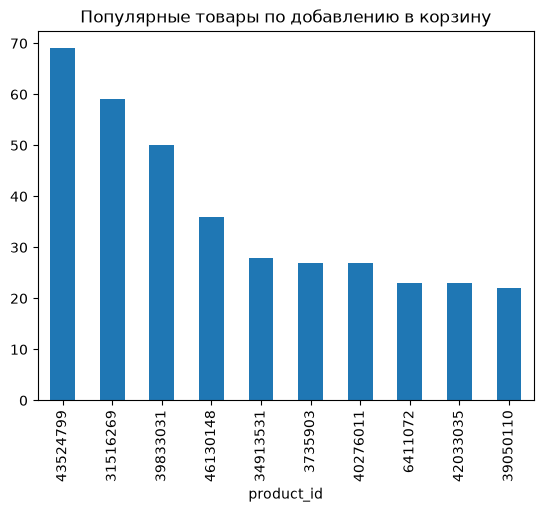

In [32]:
top_products.plot(kind="bar", title="Популярные товары по добавлению в корзину")

In [33]:
df.groupby("product_id")["basket_count"].sum().describe()

count    13161.000000
mean         2.454677
std          1.661682
min          2.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         69.000000
Name: basket_count, dtype: float64

**Медианное количество добавлений товара в корзину — 2. При этом отдельные товары значительно выделяются по активности.**


In [34]:
daily_activity = df.groupby("basket_date")["basket_count"].sum()
daily_activity

basket_date
2019-05-20    1114
2019-05-21     977
2019-05-22     593
2019-05-23     600
2019-05-24    1287
2019-05-25    2473
2019-05-26    3390
2019-05-27    3478
2019-05-28    2708
2019-05-29    1016
2019-05-30     781
2019-05-31     792
2019-06-01     629
2019-06-02     567
2019-06-03     637
2019-06-04     612
2019-06-05     441
2019-06-06     405
2019-06-07     608
2019-06-08     744
2019-06-09    1081
2019-06-10    1011
2019-06-11     911
2019-06-12     644
2019-06-13     456
2019-06-14     831
2019-06-15     866
2019-06-16     794
2019-06-17     600
2019-06-18     740
2019-06-19     520
Name: basket_count, dtype: int64

<Axes: title={'center': 'Динамика добавления товаров в корзину'}, xlabel='basket_date'>

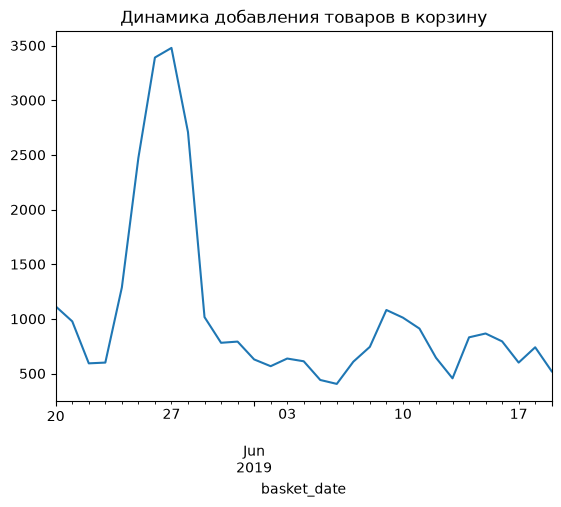

In [35]:
daily_activity.plot(title="Динамика добавления товаров в корзину")

In [36]:
period_activity = daily_activity.loc["2019-05-24":"2019-05-29"].sum()
total_activity = daily_activity.sum()
period_share = period_activity / total_activity
total_activity

np.int64(32306)

**С 24 по 29 мая, за шесть дней было совершено 14 352 добавления в корзину из 32 306 добавлений за весь период, что составляет 44,4% всей активности.**
**Проверим, какие товары чаще всего добавлялись в этот период.**

In [37]:
peak_period = df[
    (df["basket_date"] >= "2019-05-24") & (df["basket_date"] <= "2019-05-29")
]

In [38]:
peak_products = (
    peak_period.groupby("product_id")["basket_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [39]:
peak_products

product_id
31516269    27
46130148    26
43524799    26
39833031    21
34913531    16
35564684    16
39050110    16
35134963    15
42566053    15
40276001    14
Name: basket_count, dtype: int8

**В период всплеска отдельные товары добавлялись в корзину значительно чаще других.**

**Сравним топовые товары за весь период и во время всплеска.**

In [40]:
comparison = pd.concat(
    [top_products, peak_products], axis=1, keys=["all period", "peak period"]
)
comparison["%"] = (comparison["peak period"] / comparison["all period"]) * 100
comparison
# В период всплеска часть товаров заметно увеличила активность.
# У товаров 46130148 и 39050110 более 70% всех добавлений за весь период пришлись на 24–29 мая.
# Также только в топ периода всплеска вошли товары 35564684, 35134963, 42566053 и 40276001.
# Интерпретировать причины без данных о названиях и категориях товаров невозможно.

,all period,peak period,%
product_id,,,
43524799,69.0,26.0,37.681159
31516269,59.0,27.0,45.762712
39833031,50.0,21.0,42.000000
46130148,36.0,26.0,72.222222
34913531,28.0,16.0,57.142857
3735903,27.0,NaN,NaN
40276011,27.0,NaN,NaN
6411072,23.0,NaN,NaN
42033035,23.0,NaN,NaN


## Итоговый вывод

Пол, возраст и срок взаимодействия с сервисом практически не связаны с активностью корзины.

Наиболее активно за весь период добавлялись товары `43524799`, `31516269`, `39833031` и `46130148` — 69, 59, 50 и 36 добавлений соответственно.

С 24 по 29 мая наблюдался выраженный всплеск: за шесть дней было совершено 14 352 добавления из 32 306 за весь период — 44,4% всей активности. У товаров `46130148` и `39050110` более 70% всех добавлений пришлись именно на эти шесть дней. В топ периода всплеска также вошли `35564684`, `35134963`, `42566053` и `40276001`.

Точную причину всплеска определить нельзя без данных о категориях товаров, ценах, скидках и маркетинговых активностях.

## Рекомендации

- Изучить товары с наибольшей активностью, особенно в период 24–29 мая.
- Проверить акции, скидки и маркетинговые кампании в этот период.
- Дополнить данные информацией о категориях и ценах товаров, чтобы точнее интерпретировать различия в активности корзины.